# Adaptive Thiele Continued Fractions #

This Jupyter notebook contains Maple code (licensed by the MIT license below) to explore the use of the Adaptive Thiele Continued Fraction method of rational approximation to approximate the Lambert $W$ function, specifically the $-1$ branch on the interval $-8 \le W \le -1$.

© Robert M. Corless 2026 (MIT Release licence)

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


In [1]:
# Translation of Oliver Salazar Celis' Matlab code
# from https://github.com/oscelis/tcf/blob/main/tcf.m
# Translation by Robert M Corless July 2026
#
# First Version: TCF with evalhf for speed
#
# CALL:
#   evalhf(evalhftcf(m, f, x, tmp, skip, aa, ss, phi, zz, err, tol, kay, eqtm))
#
# Input:
#   m = dimension of input vectors f and x
#   f = vector complex(float[8]) of function values
#   x = vector complex(float[8]) of interpolation nodes
#   tmp = vector complex(float[8]) size m temporary work space
#   aa = vector complex(float[8]) of size nmax reciprocal differences on output
#   ss = vector complex(float[8]) of size nmax scale factors on output
#   ff = vector complex(float[8]) of size nmax chosen function values on output
#   zz = vector complex(float[8]) of size nmax 
#             chosen interpolation nodes on output
#
#   tol = positive float, usually 1.0e-13
#   k  = dimension of aa,ss,ff,zz on output
#   eqtm = 1 if scaling is to be done
evalhftcf := proc(m, f, x, tmp, skip, aa, ss, phi, zz, err, tol, kay, eqtm )
  local abstol, alpha, bigf, dt, e, i, j, k, ell, imin, imax, mindist, minf, 
        nmax, normf, skipj, tv ;
  #
  # Hardcoded workspace sizes
  #
  nmax := 250;

  minf := abs(f[1]);
  normf := minf;
  imin := 1;
  imax := 1;
  for i from 2 to m do
    tv := abs(f[i]);
    if tv > normf then
      imax := i;
      normf := tv;
    elif tv < minf then
      imin := i;
      minf := tv;
    end if;
  end do;
  
  abstol := tol*normf;   # Absolute tolerance

    for k to min(nmax,m) do # main loop
        if k=1 then # initialize
            i := imin; #smallest value
            skip[1] := i;
            aa[1] := inv_diff_cfrac(aa,zz,ss,x[i],f[i],0); # ss[1] = 1
        else
            evalhfcfrac(aa,zz,ss,x,tmp,k-1,m);
            # i was found the previous loop: location max diff
            i := imax;
            #adaptive choice
            aa[k] := inv_diff_cfrac(aa,zz,ss,x[i],f[i],k-1); 
            if abs(eqtm-1)<1/2 then # apply equivalence transformation
                alpha := 1/2;
                mindist := evalf( exp(-2*Pi*sqrt(k)/sqrt(alpha)) );
                e := 1/(abs(aa[k-1]*aa[k])+mindist);
                ss[k-1] := 2^round(log(e)/log(2)); # pow2(1,round(log2(e)));
            end if;
            aa[k] := aa[k]*ss[k-1];
        end if;
        zz[k] := x[i]; # store chosen node
        phi[k] := f[i];
        #f[i] := Float(undefined); # remove from consideration
        # We should not have to.  The interpolant should match this
        # now, so it will automatically not be the maximum error.
        evalhfcfrac(aa,zz,ss,x,tmp, k, m);
        bigf := -1;
        for j to m do
          skipj := 0;
          for ell to k-1 do
            if skip[ell]=j then 
              skipj := 1;
            end if;
          end do;
          if skipj = 0 then
            tv := abs(tmp[j]-f[j]);
            if tv>bigf then
              bigf := tv;
              imax := j;
            end if;
          end if;
        end do;
        skip[k] := imax;
        err[k] := bigf;
        if err[k] <= abstol then
          kay[1] := k;
          break
        end if;
    end do;
end proc:

kilobytes used=747, alloc=5168, time=0.20

The above procedure calls the following two auxiliary procedures.

In [2]:
# FUNCTION NAME:
#   evalhfcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac
# evalhf version: output is in r
evalhfcfrac := proc(aa, zz, ss, x, r, k, m)
  local dr, dt, i, j, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  if k>1 then
      for i from k by -1 to 2 do
          for j to m do
            r[j] :=  (x[j]*ss[i-1]-ss[i-1]*zz[i-1])/(aa[i]+r[j]);
          end do;
      end do;
  end if;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac := proc(aa,zz,ss,x,f,k)
  local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    if k>0 then
        for i to k do
            r := (ss[i]*x-ss[i]*zz[i])/(r-aa[i]);
        end do;
    end if;
    return r;
end proc:

We need the following versions for use in pzr_cfrac (not adapted as much for evalhf).  Could rewrite pzr_cfrac to use the above versions, instead, but I have not done so.

In [3]:

# FUNCTION NAME:
#   evalcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac

evalcfrac_unrolled := proc(aa::Vector,
                           zz::Vector,
                           ss::Vector, 
                           x::Vector, 
                           {k::posint := numelems(aa)},
                           {m::posint := numelems(x)})
  local dr, dt, i, j, r, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  r := Vector(m,0);
  if k>1 then
      for i from k by -1 to 2 do
          for j to m do
            r[j] :=  (x[j]*ss[i-1]-ss[i-1]*zz[i-1])/(aa[i]+r[j]);
          end do;
      end do;
  end if;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
  return r;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac_unrolled := proc(aa::Vector(datatype=float),
   zz::Vector(datatype=float),
   ss::Vector(datatype=float),x,f,k)
  local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    if k>0 then
        for i to k do
            r := (ss[i]*x-ss[i]*zz[i])/(r-aa[i]);
        end do;
    end if;
    return r;
end proc:


In [4]:
# Gemini's translation of prz_cfrac, with many errors fixed 
# and the logic of k changed
# 
# Note that it returns poles, zeros, residues
# so I have changed the name to pzr_cfrac
pzr_cfrac := proc(aa::Vector, zz::Vector, ss::Vector, 
                 {bal::truefalse := true}, 
                 {k::posint := numelems(aa)})
    local C, Dp, dt, pol, zer, res, Dl, Dr, Dz, iter, T1, T2, dz, pz, i, j, vz;
    uses LinearAlgebra;

  if Digits > 15 then
    dt := complex(float);
  else
    dt := complex(float[8]);
  end if;

    # --- POLES CALCULATION ---
    # C is a (k-1) x (k-1) matrix with superdiagonal -ss[2..(k-1)]
    C := Matrix(k-1, k-1, datatype=dt, 0 );
    for i from 1 to k-2 do
        C[i, i+1] := -ss[i+1];
    end do;

    # Dp is a (k-1) x (k-1) tridiagonal-like matrix
    Dp := Matrix(k-1, k-1, datatype=dt, 0);
    for i from 1 to k-1 do
        Dp[i, i] := aa[i+1]; # main diagonal aa[2..k]
    end do;
    for i from 1 to k-2 do
        Dp[i, i+1] := -ss[i+1] * zz[i+1]; # superdiagonal
        Dp[i+1, i] := -1;                  # subdiagonal
    end do;

    if not bal then
        pol := Eigenvalues(Dp, C);
    else
        # Call the previously defined baleig procedure
        Dl, Dr, iter := baleig(Dp, C, 5);
        T1 := DiagonalMatrix(Vector(k-1, i -> 1.0 / Dl[i]));
        T2 := DiagonalMatrix(Dr);
        pol := Eigenvalues(T1 . Dp . T2, T1 . C . T2);
    end if;
    # Filter out infinity values if any are present
    pol := Vector( select( t->type(t,complex(numeric)), convert(pol,list) ) );


    # --- ZEROS CALCULATION ---
    # C is a k x k matrix with superdiagonal -ss[1..(k-1)]
    C := Matrix(k, k, datatype=complex(float), 0);
    for i from 1 to k-1 do
        C[i, i+1] := -ss[i];
    end do;

    # Dz is a k x k matrix
    Dz := Matrix(k, k, datatype=dt, 0);
    for i from 1 to k do
        Dz[i, i] := aa[i]; # main diagonal aa[1..k]
    end do;
    for i from 1 to k-1 do
        Dz[i, i+1] := -ss[i] * zz[i]; # superdiagonal
        Dz[i+1, i] := -1;              # subdiagonal
    end do;

    if not bal then
        zer := Eigenvalues(Dz, C);
    else
        Dl, Dr, iter := baleig(Dz, C, 5);
        T1 := DiagonalMatrix(Vector(k, i -> 1.0 / Dl[i]));
        T2 := DiagonalMatrix(Dr);
        zer := Eigenvalues(T1 . Dz . T2, T1 . C . T2);
    end if;
    zer := Vector( select( t->type(t,complex(numeric)), convert(zer,list) ) );


    # --- RESIDUES CALCULATION ---
    res := Vector(Dimension(pol), datatype=dt, 0); # undefined behaves like NaN
    
    # 4-point complex circle step for approximate limit computation
    dz := Vector(4, j -> Float(1,-2-floor(Digits/4)) * exp(2.0 * I * Pi * j / 4.0));
    
    # Loop over each pole to calculate the residue
    for i from 1 to Dimension(pol) do
        pz := Vector(4, j -> pol[i] + dz[j]);
        
        # Evaluate the continued fraction at the 4 points
        vz := evalcfrac_unrolled(aa,zz,ss,pz);
        res[i] := 0;
        for j from 1 to 4 do
            res[i] := res[i] + vz[j] * dz[j];
        end do;
        res[i] := res[i] / 4.0;
    end do;

    return pol, zer, res;
end proc:

# Gemini's version of baleig, fixed up manually
baleig := proc(A::Matrix, B::Matrix, max_iter::integer)
    local n, Dl, Dr, dt, M, iter, i, j, emax, emin, d, e;
    uses LinearAlgebra;

  if Digits > 15 then
    dt := complex(float);
  else
    dt := complex(float[8]);
  end if;

    n := RowDimension(A);
    
    # Initialize scaling vectors as row vectors of ones
    Dl := Vector[row](n, datatype=dt, 1);
    Dr := Vector[row](n, datatype=dt, 1);
    
    # M = abs(A)^2 + abs(B)^2 element-wise
    M := Matrix(n, n, datatype=dt, (i,j) -> abs(A[i,j])^2 + abs(B[i,j])^2);

    for iter from 1 to max_iter do
        emax := 0;
        emin := 0;
        
        # Row scaling
        for i from 1 to n do
            # Compute row sum
            d := add(M[i,j],j=1..n);
            
            if d = 0 then
                e := 0;
            else
                e := -round(log[2](abs(d)) / 2);
            end if;
            
            # Scale the row of M by 2^(2*e)
            for j to n do
              M[i,j] := M[i,j]*2^(2*e);
            end do;
            
            # Update Dl
            Dl[i] := Dl[i] * 2^(-e);
            
            # Update bounds
            if e > emax then emax := e; end if;
            if e < emin then emin := e; end if;
        end do;
        
        # Column scaling
        for i from 1 to n do
            # Compute column sum
            d := add(M[j, i], j=1..n);
            
            if d = 0 then
                e := 0;
            else
                e := -round(log[2](abs(d)) / 2);
            end if;
            
            # Scale the column of M by 2^(2*e)
            for j to n do
              M[j, i] := M[j,i] * 2^(2*e);
            end do;
            
            # Update Dr
            Dr[i] := Dr[i] * 2^e;
            
            # Update bounds
            if e > emax then emax := e; end if;
            if e < emin then emin := e; end if;
        end do;
        
        # Stop if norms are all between 1/2 and 2
        if emax <= emin + 2 then
            break;
        end if;
    end do;

    # Return multiple values as a sequence
    return Dl, Dr, iter;
end proc:


kilobytes used=3539, alloc=9776, time=0.52

Second version of TCF code: this one can be compiled using the Maple compiler.  Unfortunately this means it is restricted to vectors of real data on input, not complex(float[8]) data as was wishfully stated in the documentation.

In [5]:
# m = dimension of input vectors f and x
# f = vector complex[8] of function values
# x = vector complex[8] of interpolation nodes
# tmp = vector complex[8] size m temporary work space
# aa = vector complex[8] of size nmax reciprocal differences on output
# ss = vector complex[8] of size nmax scale factors on output
# ff = vector complex[8] of size nmax chosen function values on output
# zz = vector complex[8] of size nmax 
#             chosen interpolation nodes on output
#
# tol = positive float, usually 1.0e-13
# k  = dimension of aa,ss,ff,zz on output
# eqtm = 1 if scaling is to be done
tcf_toc := proc(m::integer[4], f::Vector(datatype=float[8]), 
                               x::Vector(datatype=float[8]), 
                   tmp::Vector(datatype=float[8]), 
                   skip::Vector(datatype=float[8]),
                   aa::Vector(datatype=float[8]), 
                   ss::Vector(datatype=float[8]), 
                   phi::Vector(datatype=float[8]), 
                   zz::Vector(datatype=float[8]), 
                   err::Vector(datatype=float[8]), 
                   tol::float[8], 
                   kay::Vector(1,datatype=float[8]), 
                   eqtm::integer[4] )
  local abstol, alpha, bigf, dt, e, i, j, k, ell, imin, imax, mindist, minf, 
        nmax, normf, skipj, tv ;
  #
  # Hardcoded workspace sizes
  #
  nmax := 250;

  minf := abs(f[1]);
  normf := minf;
  imin := 1;
  imax := 1;
  for i from 2 to m do
    tv := abs(f[i]);
    if tv > normf then
      imax := i;
      normf := tv;
    elif tv < minf then
      imin := i;
      minf := tv;
    end if;
  end do;
  
  abstol := tol*normf;   # Absolute tolerance

    for k to min(nmax,m) do # main loop
        if k=1 then # initialize
            i := imin; #smallest value
            skip[1] := i;
            aa[1] := f[i]; # ss[1] = 1
            # find imax for next step
            bigf := -1.0;
            for j to m do
              tv := abs(f[j]-aa[1]); # constant approx
              if j<>i and tv < bigf then
                imax := j;
                bigf := tv;
              end if;
            end do;
        else
          # i was found the previous loop: location max diff
          i := imax;
          #adaptive choice
          # inline aa[k] := inv_diff_cfrac_compiled(aa,zz,ss,x[i],f[i],k-1); 
          tv := f[i];
          for j to k-1 do
            tv := (ss[j]*x[i]-ss[j]*zz[j])/(tv-aa[j]);
          end do;
          aa[k] := tv;
          if abs(eqtm-1)<1/2 then # apply equivalence transformation
            alpha := 1/2;
            mindist := evalf( exp(-2*Pi*sqrt(k)/sqrt(alpha)) );
            e := 1/(abs(aa[k-1]*aa[k])+mindist);
            ss[k-1] := exp(log(2)*round(log(e)/log(2))); # pow2(1,round(log2(e)));
          end if;
          aa[k] := aa[k]*ss[k-1];
        end if;
        zz[k] := x[i]; # store chosen node
        phi[k] := f[i];
        #f[i] := Float(undefined); # remove from consideration
        # We should not have to.  The interpolant should match this
        # now, so it will automatically not be the maximum error.
        # However, it seems we must: hence the "skip" kludge below
        # which potentially costs us an extra factor of nmax in 
        # work.  Actually k^2 where k is the final size of aa.
        # 
        # inline evalhfcfrac_compiled(aa,zz,ss,x,tmp, k, m);
        # Initialize
        for j to m do
          tmp[j] := 0.0;
        end do;
        # main body of continued fraction
        for ell from k by -1 to 2 do
          for j to m do
            tmp[j] :=  (x[j]*ss[ell-1]-ss[ell-1]*zz[ell-1])/(aa[ell]+tmp[j]);
          end do;
        end do;
        # constant term of continued fraction
        for j to m do
          tmp[j] := aa[1]+tmp[j];
        end do;

        bigf := -1;
        for j to m do
          # check if node j already processed
          # and is recorded in skip array
          # in 1 <= ell <= k-1
          skipj := 0;
          for ell to k-1 do
            if skip[ell]=j then 
              skipj := 1;
            end if;
          end do;
          # If j is not to be skipped, then
          # check if max difference occurs
          # at j
          if skipj = 0 then
            tv := abs(tmp[j]-f[j]);
            if tv>bigf then
              bigf := tv;
              imax := j;
            end if;
          end if;
        end do;
        skip[k] := imax;
        err[k] := bigf;
        if err[k] <= abstol then
          kay[1] := k;
          break
        end if;
    end do;
end proc:
# up to the user to construct R from aa, ss, and zz

# FUNCTION NAME:
#   evalhfcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac
# evalhf version: output is in r
evalcfrac_toc := proc(aa::Vector(datatype=float[8]), zz::Vector(datatype=float[8]),
                      ss::Vector(datatype=float[8]), x::Vector(datatype=float[8]),
                      r::Vector(datatype=float[8]), k, m)
  local dr, dt, i, j, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  for j to m do
    r[j] := 0;
  end do;
  if k>1 then
      for i from k by -1 to 2 do
          for j to m do
            r[j] :=  (x[j]*ss[i-1]-ss[i-1]*zz[i-1])/(aa[i]+r[j]);
          end do;
      end do;
  end if;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac_toc := proc(aa::Vector(datatype=float[8]),
   zz::Vector(datatype=float[8]),
   ss::Vector(datatype=float[8]),x,f,k)
  local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    if k>0 then
        for i to k do
            r := (ss[i]*x-ss[i]*zz[i])/(r-aa[i]);
        end do;
    end if;
    return r;
end proc:

In [6]:
evalcfrac_compiled := Compiler:-Compile(evalcfrac_toc);

kilobytes used=4535, alloc=13872, time=0.72

proc () options call_external, define_external(maple_compiled_mbe8610e14a30a466c7da57ac2136e0dc,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-4076\\maple_compiled_mbe8610e14a30a466c7da57ac2136e0dcyYxVbxdp.dll"); call_external(0,140723782293360,true,false,false,_passed) end proc

In [7]:
tcf := Compiler:-Compile(tcf_toc);

proc () options call_external, define_external(maple_compiled_m13ac2f15b66cd9f15eae1e43a5ffc4f5,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-4076\\maple_compiled_m13ac2f15b66cd9f15eae1e43a5ffc4f5h9bgQJGw.dll"); call_external(0,140723782165184,true,false,false,_passed) end proc

In [8]:
Digits := 15:
nsamples := 233:
L := -8:
U := -1:
rfloat := (i->L+(U-L)*(i-1)/(nsamples-1)):
dt := float[8]:
wvals := Vector( nsamples, datatype=dt, i->rfloat(i)):
Z := Vector( nsamples, datatype=dt, i->wvals[i]*exp(wvals[i]) ):
F := Vector( nsamples, datatype=dt, i->wvals[i] ):
tmp := Vector(nsamples, datatype=dt):
skip := Vector(nsamples, datatype=dt):
nmax := 250: # make sure it's the same in evalhfcfrac and evalhftcf
aa := Vector(nmax,datatype=dt):
ss := Vector(nmax,datatype=dt,1):
zz := Vector(nmax,datatype=dt):
phi := Vector(nmax,datatype=dt):
err := Vector(nmax,datatype=dt):
tol := Float(1,-13)/8.0:
k := Vector(1,datatype=dt):
eqtm := 1:

In [9]:
st := time():
tcf( nsamples, F, Z, tmp, skip, aa, ss, phi, zz, err, tol, k, eqtm ):
time_taken := time()-st;

$$ 0.031$$

In [10]:
last := round(k[1]);

$$44$$

In [11]:
evalf[7](convert(zz[1..last],list));

| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-.3678794|-.2683701e-2|-.6910826e-1|-.1439911e-1|-.3332434|-.2041526|-.3366019|-.5443673e-2|-.3664603|-.3334291e-1|-.3398535|-.3677153|-.2549539|-.3492004e-2|-.3672360|-.3625316|-.1147873|-.8886941e-2|-.3654063|-.1563467|-.2200638e-1|-.3565383|-.3777889e-2|-.2915797|-.3640912|-.4882990e-1|-.2904714e-2|-.3607430|-.9044627e-1|-.3113327|-.7051775e-2|-.3515889|-.2270115|-.1146846e-1|-.3587404|-.2745350e-1|-.2995859|-.2755477e-2|-.5750119e-1|-.1791989|-.4549533e-1|-.3488671|-.4536780e-2|-.2712539|


AAA instead chose these 21 nodes, in this order:
[- 0.002683701, - 0.3678794, - 0.09451194, - 0.2549539, - 0.3515889, - 0.01369136, - 0.3664603, - 0.03760550, - 0.3074599, - 0.3672360, - 0.004656678, - 0.1826393, - 0.3640912, - 0.007424751, - 0.3429884, - 0.05618192, - 0.3607430, - 0.003227307, - 0.1413733, - 0.02094393, - 0.3297871, - 0.3565383, - 0.3677153, - 0.002982272]

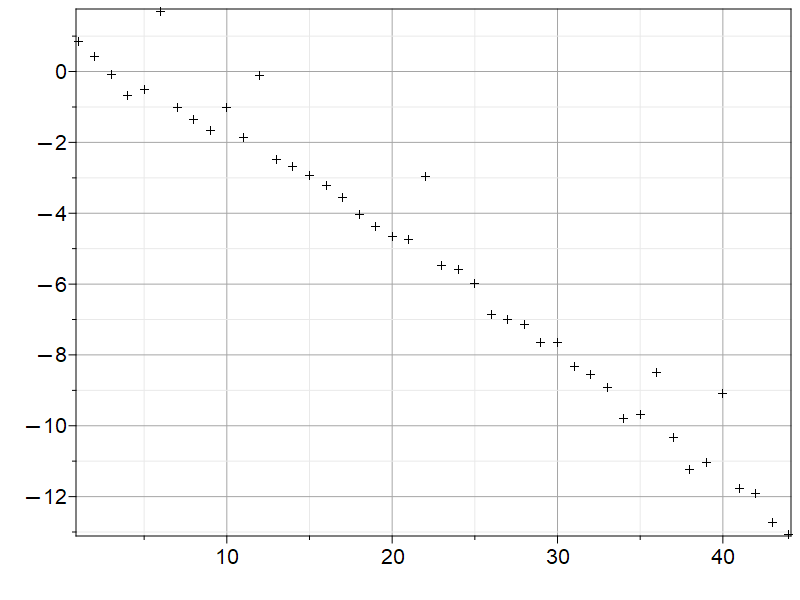

In [12]:
plot( [seq(j,j=1..last)],
      [seq(log[10](abs(err[j])),j=1..last)] , 
 style=point, symbol=cross, gridlines );

In [13]:
aa[1..last];

In [14]:
err[1..last];

In [15]:
aaw := aa[1..last]:
ssw := ss[1..last]:
zzw := zz[1..last]:
phiw := phi[1..last];
ntest := 10*nsamples:
wtest := Vector(ntest, datatype=float[8], i->(L+(i-1)*(U-L)/(ntest-1))):
xtest := Vector(ntest, datatype=float[8], i->wtest[i]*exp(wtest[i])):
tmp := Vector(ntest, datatype=float[8]):
CodeTools:-Usage( evalcfrac_compiled( aaw, zzw, ssw, xtest, tmp, last, ntest ) ):

memory used=1.26KiB, alloc change=0 bytes, cpu time=16.00ms, real time=3.00ms, gc time=0ns

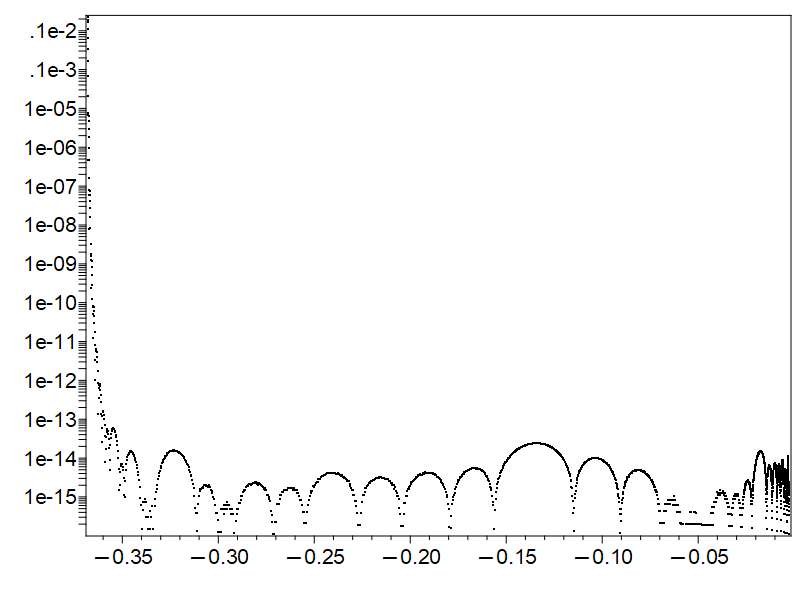

In [16]:
abserr := tmp-wtest:
ferr := Vector(ntest, i->(tmp[i] - wtest[i])/wtest[i]):
plots[logplot]( xtest, abs(ferr), style=point, symbol=point );

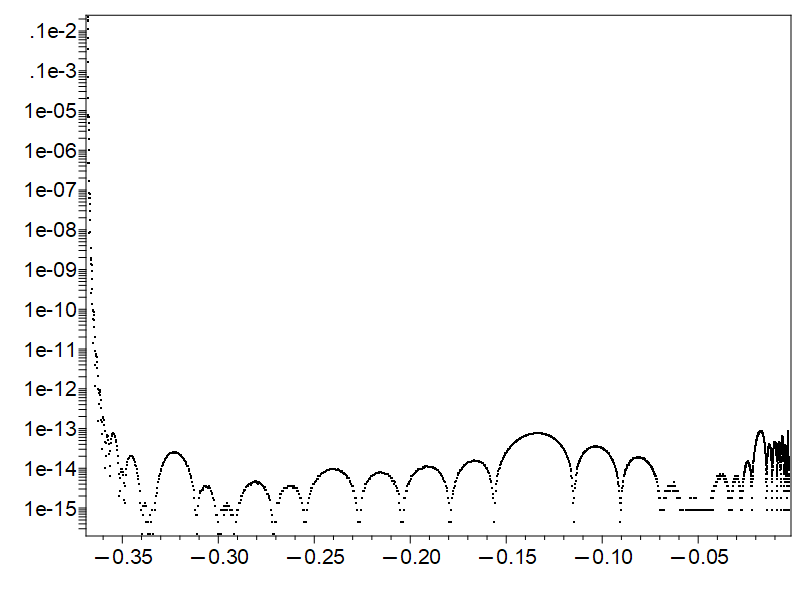

In [17]:
plots[logplot](xtest, abs(abserr), style=point, symbol=point);

In [18]:
(pol,zer,res) := CodeTools:-Usage( pzr_cfrac( aaw, zzw, ssw ) ):

memory used=10.64MiB, alloc change=0 bytes, cpu time=438.00ms, real time=432.00ms, gc time=0ns

In [19]:
evalf[4](convert(pol,list));

| | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|.5724-.9272e-14*I|-.7915-.3700e-13*I|.1971-.1395e-14*I|-.5191+.1573e-13*I|-.4366+.4062e-16*I|-.4014+.1168e-13*I|-.3844-.2164e-12*I|-.3757+.3152e-11*I|-.3713-.3221e-10*I|-.3692+.1680e-9*I|-.3679+.2509e-9*I|-.3682-.3896e-9*I|.9021e-1-.1169e-16*I|.4539e-1-.1701e-15*I|.2358e-1+.2650e-15*I|.1222e-1-.1411e-15*I|.6120e-2+.1373e-15*I|.2811e-2-.2211e-13*I|.1048e-2+.7584e-13*I|.1977e-3-.4938e-13*I|-.5962e-3-.4571e-14*I|


In [20]:
# ClusterComplexRoots.mpl
#
# clusteredList := ClusterComplexRoots( rootList, tolerance=s, MaxOrder=M );
#
# Take a list rootList of complex numbers and cluster them
# according to apparent multiplicity.
#
# This routine is heuristic (the problem is hard) and is intended
# to work only up to the given maximum order (default MaxOrder is 3)
#
# The routine uses distances and a fuzz factor F[m] and only considers
# neighbouring points up to about |r[i]-r[j]| <= F[m]*s^(1/m) to be
# possible candidates for a cluster; it also uses approximate 
# angle symmetry, looking for angles between adjacent roots to be
# approximately 2*Pi/m .
#
# The returned clusteredList will be a list of pairs [r,m] where
# r is the mean of the original cluster of m roots.
# -----------------------------------------------------------------------------
# (c) Robert M. Corless and Leili Rafiee Sevyeri 2020 (MIT Release licence)
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# -------------------------------------------------------------------------------

ClusterComplexRoots := proc( rootList::list, 
                            {tolerance::numeric := Float(1,2-Digits)}, 
                            {MaxOrder::nonnegint := 3}, $ )
    local anglesequal, 
          c, closeenough, closeNeighbours, clustered, combos, countem, 
          DistanceMatrix, exactangle, finished_combos, Fuzz,
          i, j, k, m, max_radius, mean, 
          n, neighbours, notInAcluster, nroots, 
          phasedifference, phases, phaseorder, 
          r, radius, trialcluster, trialindices, unseen_m;


    # Safety factors for distance computations.
    # They essentially replace the factor m!*B(r)/(D@@m)(f)(r)
    # which connects the root semimetric with the coefficient
    # metric; in this implementation, no account is taken of
    # the problem in this way (but it can be done in a post-
    # processing validation step).
    Fuzz := Array(2..MaxOrder);
    for m from 2 to MaxOrder do
      Fuzz[m] := evalf(2^(1/m));
    od;

    # Process small rootlists
    nroots := numelems( rootList );
    if nroots=0 then
      error "cannot cluster an empty list of roots";
    elif nroots=1 then
      # Return a cluster of 1
      return [[rootList[1],1]];
    end if;

    # nroots>=2 from now on
    # We will need distances between roots
    # -- to identify "close" roots
    # -- to ignore "far" roots
    DistanceMatrix := Matrix( nroots, nroots, 'shape'='symmetric' );
    for i to nroots do
      for j to nroots do
        DistanceMatrix[i,j] := evalf( abs( rootList[i] - rootList[j]) ) ;
      od;
    od;

    # We order neighbours from nearest to farthest
    neighbours := Array(1..nroots);
    for i to nroots do
      neighbours[i] := sort( [seq(DistanceMatrix[i,j],j=1..nroots)], 
                              'output'='permutation');
      # neighbours[i] should be a list of integers such that
      # the nearest root to rootList[i] should be 
      # rootList[neighbours[i][1]] (itself), the next nearest should be
      # rootList[neighbours[i][2]], and so on
    od;

    # Now begin the clustering.  We start with no clustered roots at all.
    clustered := NULL;
    # The notInAcluster roots are, at the start, all of them.
    # This states that we *assume* these are not in any m-cluster
    # for m > MaxOrder.
    notInAcluster := seq(k,k=1..nroots); 
    for m from MaxOrder by -1 to 2 do
      # The sequence "notInAcluster" can shrink inside this loop
      # The list unseen_m tracks which roots we haven't yet
      # considered for any cluster at level m
      unseen_m := [notInAcluster]; # never any duplicates
      notInAcluster := NULL; # means known not to be part of any m-cluster
      # Assert nroots in clustered, notInAcluster,unseen_m +0(i)
      while numelems(unseen_m) >= m do
        # Checking for m-cycles over all elements of unseen_m
        i := unseen_m[1];
        # print("considering root", i, "or", rootList[i], "for cycles of length", m);
        unseen_m := unseen_m[2..numelems(unseen_m)]; # Assert nroots-1 + 1(i)
        # the root under consideration is rootList[i]
        # we try to find an m-cluster with this in it
        # No need to consider roots farther away than 
        # twice the distance to the centre of any m-cluster
        # to this tolerance
        k := nroots;
        while k > 0 and 
              DistanceMatrix[i,neighbours[i][k]] > 2*Fuzz[m]*tolerance^(1/m) do
          k := k-1;
        od;
        closeNeighbours := {seq(neighbours[i][j], j=2..k)}; # might be empty
        closeNeighbours := closeNeighbours intersect convert(unseen_m,set);
        closeNeighbours := convert(closeNeighbours,list);
        # examine all sets of m-1 close neighbours
        n := numelems(closeNeighbours); # <= k-1
        if n>=m-1 then
          # Now look at all possible choices of m-clusters
          # from the set of close neighbours
          combos := Iterator:-Combination( n, m-1 ); # at least 1
          finished_combos := false;
          for c in combos do
            # Iterator:-Combination indexes from 0 but lists index from 1
            trialindices := [i,seq(closeNeighbours[c[k]+1],k=1..m-1)];
            trialcluster := seq( rootList[k], k in trialindices );
            mean := evalf( add( r, r in [trialcluster] )/m );
            # Check the distances
            closeenough := true;
            max_radius := 0;
            for r in trialcluster do
              radius := abs(r-mean);
              max_radius := max( max_radius, radius ); 
              if radius > Fuzz[m]*tolerance^(1/m) then
                closeenough := false;
                break;
              end if;
            od;
            if closeenough then
              # Now check the angles
              # May be nonsense if max_radius=0
              anglesequal := true;
              if max_radius >= Float(1,1-Digits) then
                phases := [seq( argument( trialcluster[k]-mean), k=1..m) ];
                phaseorder := sort( phases, 'output'='permutation' );
                trialcluster := [seq( trialcluster[phaseorder[k]], k=1..m)];
                phases := [seq( phases[phaseorder[k]], k=1..m)];
                # Now check if all the angles are approximately equal
                exactangle := evalf(2*Pi/m);
                for k from 2 to m do
                  phasedifference := phases[k]-phases[k-1];
                  # Heuristic: what constitutes approximately equal angle?
                  if 0.75*exactangle > phasedifference or
                      phasedifference > 1.25*exactangle then
                    anglesequal := false;
                    break; # no need to consider this trial cluster further
                  end if;
                end do; # exit this loop on break for unequal angles
              end if;
              # closeenough is true, remember
              if anglesequal then
                # We have found a cluster of m roots
                clustered := [mean,m,trialcluster],clustered;
                # print([clustered], unseen_m);
                unseen_m := remove( k->member(k,convert(trialindices,set)), 
                                    unseen_m );
                # print("removed",trialindices,"got",unseen_m);
                # Assert nroots + 1(i)
                break; # stop considering rootList[i]
              end if;
            # else Not close enough to be a cluster.
            end if; 
            finished_combos := Rank(combos)=Number(combos);
            # Go look at the other choices of m-1 elements
          end do; # end for c in combos do; exit this loop via break for found cluster
          # stop looking at rootList[i] but keep looking for m-clusters
          if finished_combos then
            # Loop finished without finding a cluster
            notInAcluster := i,notInAcluster;
            # else We did find a cluster and have seen i
          end if;
          # print(m,"unseen_m",unseen_m);
        else
          # Not enough close neighbours to form an m-cycle
          notInAcluster := i, notInAcluster;
        end if;
      end do; # end while unseen_m has more than m elts do
      # Now look at clusters of smaller order
      for k in unseen_m do
        notInAcluster := k,notInAcluster;
      od;
      unseen_m := [];
    end do;
    # Everything left over is a 1-cluster
    notInAcluster := [notInAcluster];
    return [clustered, seq( [rootList[notInAcluster[k]],1], 
                            k=1..numelems(notInAcluster)) ];
  end proc:


In [21]:
cp := ClusterComplexRoots( convert(pol,list), 
'tolerance'=Float(1,-9) );

| | |
|:-:|:-:|
|.572410348834905-9.27200549243981e-015*I|1|
|-.791464101678288-3.69977430604913e-014*I|1|
|.197068741050251-1.39521161439108e-015*I|1|
|-.519141345292083+1.57272388592678e-014*I|1|
|-.436598181792694+4.06154038843925e-017*I|1|
|-.401394156764967+1.16756358086189e-014*I|1|
|-.384376118280169-2.16350550320295e-013*I|1|
|-.375743547447937+3.1524263614661e-012*I|1|
|-.371345332348891-3.22141801512147e-011*I|1|
|-.369186348967863+1.67956092264249e-010*I|1|
|-.367910562405687+2.50912951428553e-010*I|1|
|-.368231780558999-3.89602342665664e-010*I|1|
|.0902097913374667-1.16868811065727e-017*I|1|
|.0453913162773834-1.70077381387511e-016*I|1|
|.0235849460224279+2.65032389893719e-016*I|1|
|.012224426712338-1.41062854242909e-016*I|1|
|.00611953681240939+1.37267804666362e-016*I|1|
|.00281073929831279-2.2105790531845e-014*I|1|
|.00104771501779137+7.58381229497018e-014*I|1|
|.000197692971049572-4.9377419203554e-014*I|1|
|-.000596210976784012-4.57073990582364e-015*I|1|


In [22]:
#cp := ClusterComplexRoots( convert(pol,list), 'tolerance'=Float(1,-7) );

In [23]:
numelems(pol);

$$21$$

In [24]:
#lprint( cp[1] );

In [25]:
#cz := ClusterComplexRoots( convert(zer, list), 'tolerance'=Float(1,-7));

In [26]:
#lprint(cz[1]);

In [27]:
numelems(pol);

$$21$$

In [28]:
numelems(zer);

$$22$$

In [29]:
numelems(phiw);

$$44$$

In [30]:
numelems(zzw);

$$44$$

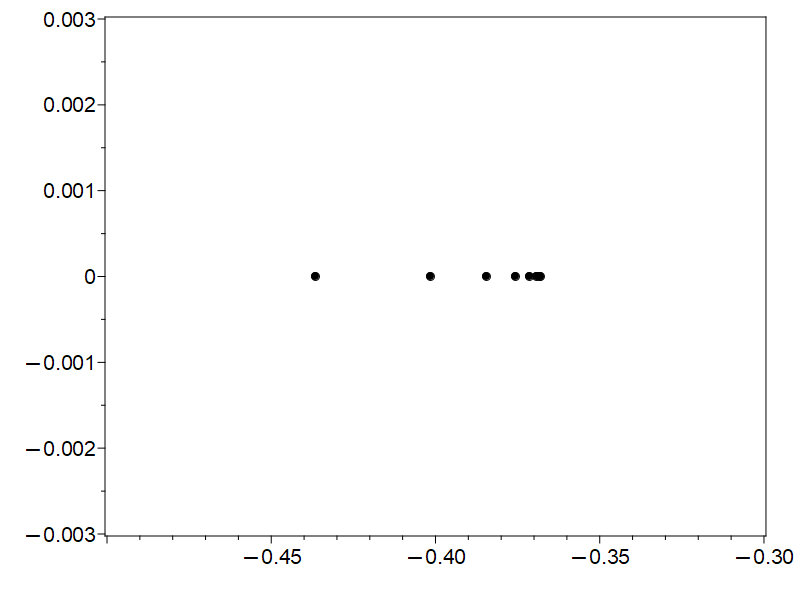

In [31]:
plots[pointplot]( map(Re,pol), map(Im,pol), style=point, 
symbol=solidcircle, view=[-0.5..-0.3,-0.003..0.003]);

## Accurate computation of poles, zeros, residues ##

In [32]:
#evalhfcfrac := proc(aa, zz, ss, x, r, k, m)
X := Vector(1,symbol=x):
Rsymb := Vector(1,0):
evalhfcfrac( aaw, zzw, ssw, X, Rsymb, numelems(aaw), 1):

In [33]:
RR := convert( Rsymb[1], rational );

$$-1+\frac{16 x_{1}+\frac{15387055}{2614147}}{-\frac{4281938}{5129709}+\frac{16 x_{1}+\frac{3061365}{71295316}}{\frac{7997673}{5407136}+\frac{8 x_{1}+\frac{15552071}{28129906}}{-\frac{4784175}{9045901}+\frac{2 x_{1}+\frac{1241625}{43114646}}{-\frac{51095572}{33931915}+\frac{128 x_{1}+\frac{133767796}{3136029}}{-\frac{10061312}{16340801}+\frac{128 x_{1}+\frac{210598316}{8059165}}{\frac{17546516}{7931931}+\frac{2 x_{1}+\frac{2039339}{3029304}}{-\frac{4848538}{7921383}+\frac{2 x_{1}+\frac{1074606}{98702297}}{-\frac{1801691}{1316865}+\frac{8 x_{1}+\frac{40518089}{13820764}}{\frac{10678663}{13713047}+\frac{8 x_{1}+\frac{12142204}{45520193}}{\frac{9047457}{5815037}+\frac{32 x_{1}+\frac{86597531}{7962763}}{-\frac{2253581}{2623363}+\frac{64 x_{1}+\frac{32915969}{1398669}}{-\frac{27579911}{18107976}+\frac{4 x_{1}+\frac{12971479}{12719436}}{-\frac{8947402}{12368897}+\frac{x_{1}+\frac{1031100}{295274569}}{-\frac{12210159}{12344860}+\frac{64 x_{1}+\frac{76983001}{3275440}}{-\frac{20735919}{17017826}+\frac{32 x_{1}+\frac{21982046}{1894839}}{\frac{4344344}{6697237}+\frac{2 x_{1}+\frac{1704165}{7423142}}{-\frac{10815699}{6721361}+\frac{4 x_{1}+\frac{1783739}{50178654}}{-\frac{4439404}{6336999}+\frac{16 x_{1}+\frac{56557587}{9673750}}{-\frac{7779662}{6318483}+\frac{32 x_{1}+\frac{69634771}{13918337}}{\frac{13804913}{16807732}+\frac{16 x_{1}+\frac{7323860}{20800387}}{-\frac{10955740}{10387947}+\frac{4 x_{1}+\frac{16019549}{11232700}}{-\frac{39879377}{39898251}+\frac{4 x_{1}+\frac{2190143}{144931686}}{-\frac{5734265}{4351048}+\frac{2 x_{1}+\frac{17002631}{29156057}}{\frac{13800377}{19433069}+\frac{x_{1}+\frac{3799508}{10435593}}{-\frac{8065981}{5760654}+\frac{\frac{x_{1}}{2}+\frac{607491}{24881926}}{-\frac{101162258}{115486939}+\frac{2 x_{1}+\frac{770143}{132567788}}{-\frac{27933583}{29347642}+\frac{2 x_{1}+\frac{12994123}{18010224}}{\frac{6880851}{8783924}+\frac{\frac{x_{1}}{2}+\frac{2585662}{57175649}}{-\frac{12940951}{8055432}+\frac{x_{1}+\frac{8740531}{28074571}}{-\frac{5721053}{8703528}+\frac{2 x_{1}+\frac{1828877}{129674939}}{-\frac{7707797}{6659904}+\frac{2 x_{1}+\frac{7427429}{10562661}}{\frac{12042451}{16584028}+\frac{\frac{x_{1}}{2}+\frac{5318223}{46854209}}{-\frac{6271081}{5757305}+\frac{2 x_{1}+\frac{4465819}{194700007}}{-\frac{4223927}{5415520}+\frac{8 x_{1}+\frac{9235557}{3218050}}{\frac{9420877}{6022640}+\frac{8 x_{1}+\frac{2579939}{11746858}}{\frac{12084247}{18003413}+\frac{2 x_{1}+\frac{10773297}{17980315}}{-\frac{4028588}{3193881}+\frac{2 x_{1}+\frac{1650779}{299545056}}{\frac{12372301}{20470612}+\frac{128 x_{1}+\frac{7873111}{1069694}}{-\frac{21419957}{10555518}+\frac{64 x_{1}+\frac{77549047}{6761783}}{-\frac{14211413}{20647417}+\frac{x_{1}+\frac{692138}{15213387}}{-\frac{6674983}{5687529}+\frac{2 x_{1}+\frac{12208939}{17497978}}{\frac{1878413}{2902095}-\frac{10479527 x_{1}}{500611}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}$$

In [34]:
argh := normal(RR):

In [35]:
okthen := asympt(leadterm(argh),x[1]):

In [36]:
Digits := 30;

$$30$$

In [37]:
evalf(okthen);

$$- 1.44633925625801230335932929725 x_{1}$$

In [38]:
evalf[30](eval(RR,x[1]=-exp(-1))-LambertW(-1,-exp(-1)));

$${ 6.23897931820766564165248118393\times 10^{-13}}$$

In [39]:
degree(denom(argh),x[1]);

$$21$$

In [40]:
trzeros := [fsolve(numer(argh),x[1], 'complex')];

| | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-1.38775535332536081703810402796|-.654310535645404409776238592632|-.491705876972053560057396230848|-.428351175227194327825079821180|-.398526401686216692372039210227|-.383329279995955067063989107702|-.375364842406294040540085071483|-.371216907082342691351828011759|-.369148889485981009244546331485|-.368224016363168537572852170755|-.367910042236744648188758931398|-.596177589438920743099599791624e-3|.250662869188380176911583643848e-3|.120077070446996042730246572432e-2|.314634695474119675473825800853e-2|.681800964550707926687936307795e-2|.136754499796935475613255176008e-1|.266790640140282672685645771420e-1|.524054245171015028942150571773e-1|.108252558627262341174105512330|.258863991554262146183538598567|1.13175973490585040257443452284|


In [41]:
lprint(trzeros);

[-1.38775535332536081703810402796, -.654310535645404409776238592632, -.491705876972053560057396230848, -.428351175227194327825079821180, -.398526401686216692372039210227, -.383329279995955067063989107702, -.375364842406294040540085071483, -.371216907082342691351828011759, -.369148889485981009244546331485, -.368224016363168537572852170755, -.367910042236744648188758931398, -.596177589438920743099599791624e-3, .250662869188380176911583643848e-3, .120077070446996042730246572432e-2, .314634695474119675473825800853e-2, .681800964550707926687936307795e-2, .136754499796935475613255176008e-1, .266790640140282672685645771420e-1, .524054245171015028942150571773e-1, .108252558627262341174105512330, .258863991554262146183538598567, 1.13175973490585040257443452284]

In [42]:
troops := [fsolve( denom(argh), x[1], 'complex')];

| | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-.791464101678318221611551431742|-.519141345292062782300091841821|-.436598181792697962362396259221|-.401394156764706758465702789980|-.384376118284339488565178188221|-.375743547465764801899854014460|-.371345331655380492161368184139|-.369186353512302747672887217508|-.368231769302905427224254671079|-.367910569789096132876879478986|-.596210976649313286932459835727e-3|.197692970816055710257030157601e-3|.104771501775444437178541635792e-2|.281073929855668904804808805221e-2|.611953681227845044064546226328e-2|.122244267123662211282022630455e-1|.235849460224186195892359360160e-1|.453913162773890114179247391844e-1|.902097913374669799762229652391e-1|.197068741050247731913662048941|.572410348834914728434000224909|


In [43]:
lprint(troops);

[-.791464101678318221611551431742, -.519141345292062782300091841821, -.436598181792697962362396259221, -.401394156764706758465702789980, -.384376118284339488565178188221, -.375743547465764801899854014460, -.371345331655380492161368184139, -.369186353512302747672887217508, -.368231769302905427224254671079, -.367910569789096132876879478986, -.596210976649313286932459835727e-3, .197692970816055710257030157601e-3, .104771501775444437178541635792e-2, .281073929855668904804808805221e-2, .611953681227845044064546226328e-2, .122244267123662211282022630455e-1, .235849460224186195892359360160e-1, .453913162773890114179247391844e-1, .902097913374669799762229652391e-1, .197068741050247731913662048941, .572410348834914728434000224909]

In [44]:
alf := evalf(okthen/x[1]);

$$- 1.44633925625801230335932929725$$

In [45]:
barywts := k -> alf*mul( troops[k]-trzeros[j], j=1..numelems(trzeros))/mul(troops[k]-troops[j],j=1..k-1)/mul(troops[k]-troops[j],j=k+1..numelems(troops));

k -> local j; alf*mul(troops[k]-trzeros[j],j = 1 .. numelems(trzeros))/mul(troops[k]-troops[j],j = 1 .. k-1)/mul(troops[k]-troops[j],j = k+1 .. numelems(troops))

In [46]:
numelems(troops);

$$21$$

In [47]:
residues := [seq(barywts(k),k=1..numelems(troops))];

| | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|.209213441734183176581851908095|.337569171654207470477516506516e-1|.937641253910533914175278399882e-2|.312981851812272891389014032786e-2|.111431561351931888611508772986e-2|.396431564474458396001643791673e-3|.132857724047971223152479957511e-3|.384229542754868214009141631644e-4|.789845485893300519905010837353e-5|.534577467286047612953102576336e-6|.323650967250367766412083914151e-6|.549741240697414006888586352211e-3|.138169307076747469899026715149e-2|.270748299010593852464992586953e-2|.508231267122826997965055821321e-2|.952280703977459562983132191449e-2|.181962917685528456609224729728e-1|.364424276270154886269828827521e-1|.804540725439982714144393733672e-1|.219644139608946944772184333208|1.07783403145751068780253487404|


In [48]:
lprint(residues);

[.209213441734183176581851908095, .337569171654207470477516506516e-1, .937641253910533914175278399882e-2, .312981851812272891389014032786e-2, .111431561351931888611508772986e-2, .396431564474458396001643791673e-3, .132857724047971223152479957511e-3, .384229542754868214009141631644e-4, .789845485893300519905010837353e-5, .534577467286047612953102576336e-6, .323650967250367766412083914151e-6, .549741240697414006888586352211e-3, .138169307076747469899026715149e-2, .270748299010593852464992586953e-2, .508231267122826997965055821321e-2, .952280703977459562983132191449e-2, .181962917685528456609224729728e-1, .364424276270154886269828827521e-1, .804540725439982714144393733672e-1, .219644139608946944772184333208, 1.07783403145751068780253487404]

In [49]:
latex(residues);

[ 0.209213441734183176581851908095,  0.0337569171654207470477516506516,  0.00937641253910533914175278399882,  0.00312981851812272891389014032786,  0.00111431561351931888611508772986,  0.000396431564474458396001643791673,  0.000132857724047971223152479957511,  0.0000384229542754868214009141631644, { 7.89845485893300519905010837353\times 10^{-6}}, { 5.34577467286047612953102576336\times 10^{-7}}, { 3.23650967250367766412083914151\times 10^{-7}},  0.000549741240697414006888586352211,  0.00138169307076747469899026715149,  0.00270748299010593852464992586953,  0.00508231267122826997965055821321,  0.00952280703977459562983132191449,  0.0181962917685528456609224729728,  0.0364424276270154886269828827521,  0.0804540725439982714144393733672,  0.219644139608946944772184333208,  1.07783403145751068780253487404]

## Conversion of TCF to barycentric form ##

In this section we do a (small) SVD computation to get a set of barycentric weights that compresses the TCF form.  From there we compute accurate poles and zeros of the compressed form, which allows us to write the TCF form in a product form:
\begin{equation}
K \frac{ \prod_{i=1}^m (x-z_i) }{\prod_{j=1}^n (x-p_j)}
\end{equation}

In [50]:
numelems(phiw);

$$44$$

In [51]:
nw := numelems(zzw);

$$44$$

In [52]:
inds := sort(zzw, output=permutation );

| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|1|12|15|9|19|25|16|28|35|22|32|42|11|7|5|30|37|24|44|13|33|6|40|20|17|29|3|39|26|41|10|36|21|4|34|18|31|8|43|23|14|27|38|2|


In [53]:
Digits := 15;

$$15$$

In [54]:
zzwi := [seq(zzw[inds[j]], j=1..nw)]:
phiwi := [seq(phiw[inds[j]], j=1..nw)]:
nout := 2*nw-2:
xswi := Vector(nout,[seq( op([zzwi[j]+(zzwi[j+1]-zzwi[j])/4,
                 zzwi[j]+3*(zzwi[j+1]-zzwi[j])/4]), 
                 j=1..numelems(zzwi)-1)] ):
yswi := Vector(nout):
evalhfcfrac( aaw, zzw, ssw, xswi, yswi, numelems(aaw), nout):

kilobytes used=14275, alloc=18856, time=3.14

In [55]:
lprint(evalf[7](zzwi));

[-.3678794, -.3677153, -.3672360, -.3664603, -.3654063, -.3640912, -.3625316, -.3607430, -.3587404, -.3565383, -.3515889, -.3488671, -.3398535, -.3366019, -.3332434, -.3113327, -.2995859, -.2915797, -.2712539, -.2549539, -.2270115, -.2041526, -.1791989, -.1563467, -.1147873, -.9044627e-1, -.6910826e-1, -.5750119e-1, -.4882990e-1, -.4549533e-1, -.3334291e-1, -.2745350e-1, -.2200638e-1, -.1439911e-1, -.1146846e-1, -.8886941e-2, -.7051775e-2, -.5443673e-2, -.4536780e-2, -.3777889e-2, -.3492004e-2, -.2904714e-2, -.2755477e-2, -.2683701e-2]

In [56]:
hs := [seq(zzwi[j+1]-zzwi[j], j=1..nw-1)];

| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|.000164123519444892|.000479346110769774|.000775685771207735|.0010539865065492|.00131505883276423|.00155968102117482|.00178860029919542|.00200253400817901|.00220217071986306|.00494934132335934|.00272177538165613|.0090136416294872|.00325159013144743|.00335852511533741|.0219107160917221|.0117467842616956|.00800614111589532|.0203258329306021|.016300011432792|.0279423579684967|.0228589549705231|.0249537140125154|.0228521296276881|.0415594286488069|.02434104300878|.0213380061137681|.0116070689802062|.00867128996511221|.00333457574662458|.0121524202838798|.00588940488450421|.00544711933766388|.0076072721240166|.00293064797203224|.0025815200757157|.00183516619372796|.00160810235024788|.000906892913083593|.000758891289698875|.000285884420083824|.000587290154690702|.000149236967400696|7.17759358120707e-005|


In [57]:
min(hs);

$$ 0.0000717759358120706806$$

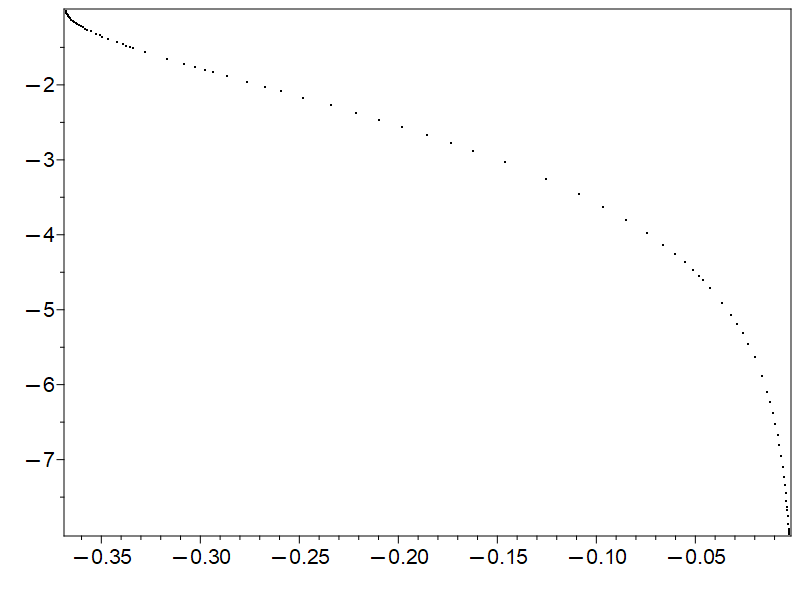

In [58]:
plot( xswi, yswi, style=point, symbol=point );

In [59]:
Digits := 15:
nrows := nout:
ncols := 22; #nw; #floor( nw/2 ) + 1: #
A := Matrix(nrows,ncols, (i,j)->(yswi[i]-phiw[j])/(xswi[i]-zzw[j])):

                                  ncols := 22

In [60]:
(U,S,Vt) := LinearAlgebra:-SingularValues(A, output=['U','S','Vt']):

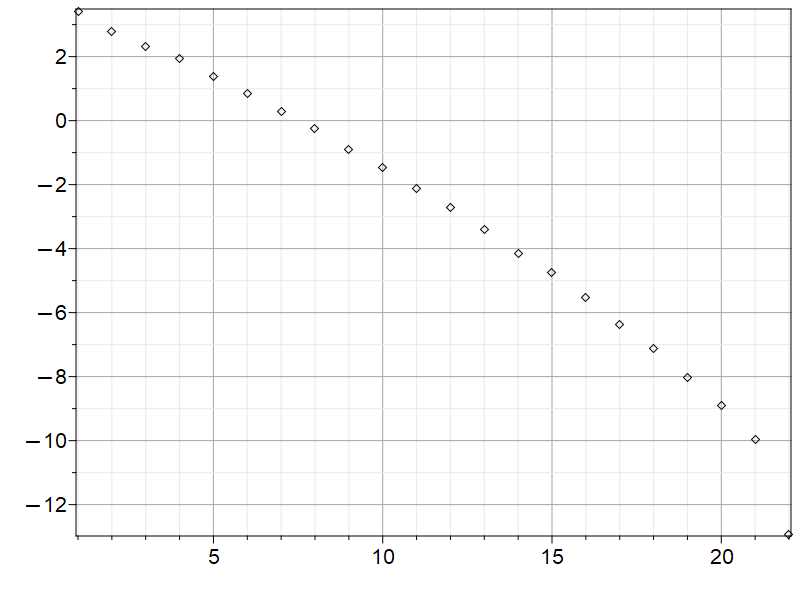

In [61]:
plot( [seq([k,log10(S[k])],k=1..ncols)], style=point, gridlines );

In [62]:
CMPL := proc( p::{list,Vector}, tau::{list,Vector}, gam::{list,Vector}, $ )
   local C0, C1, n, i, j, k, d;
   n := numelems(tau);

   d := n - 1;

   C1 := Matrix( d+2, d+2, (i,j)->`if`(i<>j,0,`if`(i=1,0,1)) );
   C0 := Matrix( d+2, d+2, 0 );
   k := 0;
   for i from 1 to n do
     C0[i+1,i+1]   :=  tau[i];
     C0[i+1,1]     := -gam[i];
     C0[1,i+1]     :=  p[i];
   end do;
   return C0, C1
end proc:

In [63]:
ncols, nw;

$$22$$,$$44$$

In [64]:
barywts := [seq(Vt[ncols,j],j=1..ncols)];

| | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-6.36269773240536e-005|2.36233531067314e-006|-.00100733955144067|.000317398595600276|.377461199512018|.0075618653225766|-.805869356868754|3.58220081095699e-005|.0285069559013494|.000622936056415591|.450663111442128|.00124505452485748|-.00641397736630132|-1.03804465296083e-005|-.00884488236956467|.0341961048789007|.0031777938282746|-.000115097579447631|-.0380514306777632|-.00619604616844031|-.000585232012449889|-.0366332351204302|


In [65]:
Digits := 15:
(C0z,C1z) := CMPL( phiw[1..ncols], zzw[1..ncols], barywts );

In [66]:
zeroest := LinearAlgebra:-Eigenvalues( C0z, C1z ):
finitezeros := sort( map( Re, select(t->type(t,complex(numeric)), convert(zeroest,list)) )):
"Zeros", latex( evalf[7]( finitezeros ));

[- 1.405758, - 0.6555773, - 0.4918693, - 0.4283722, - 0.3985286, - 0.3833295, - 0.3753649, - 0.3712169, - 0.3691489, - 0.3682240, - 0.3679100,  0.0001945236,  0.0009985594,  0.002738989,  0.006114719,  0.01252843,  0.02485879,  0.04954049,  0.1035545,  0.2493739,  1.072645]

"Zeros"

In [67]:
numelems(finitezeros);

$$21$$

In [68]:
Digits := 15:
(C0p,C1p) := CMPL( [seq(1.0,j=1..ncols)], zzw[1..ncols], [seq(Vt[ncols,j],j=1..ncols)] ):

In [69]:
polest := LinearAlgebra:-Eigenvalues( C0p, C1p ):
finitepoles := sort( map( Re, select(t->type(t,complex(numeric)), convert(polest,list)) )):
"Poles", latex( evalf[7](finitepoles ));

[- 0.7949392, - 0.5194409, - 0.4366312, - 0.4013973, - 0.3843763, - 0.3757436, - 0.3713453, - 0.3691864, - 0.3682318, - 0.3679106,  0.0001532797,  0.0008681998,  0.002440324,  0.005477999,  0.01118285,  0.02194710,  0.04285705,  0.08622111,  0.1899974,  0.5519998,  48.27600]

"Poles"

In [70]:
numelems(finitepoles);

$$21$$

In [71]:
tb := x -> mul( x-zz, zz in finitezeros)/mul( x-pp, pp in finitepoles ):

In [72]:
LambertW(-1, -2.0*exp(-2.0));

$$- 2.0$$

In [73]:
K := -2.0/tb(-2.0*exp(-2.0));

$$ 71.1281847115036641$$

In [74]:
BaryTCFW0 := x -> K*tb(x);

x -> K*tb(x)

kilobytes used=48438, alloc=18856, time=6.42

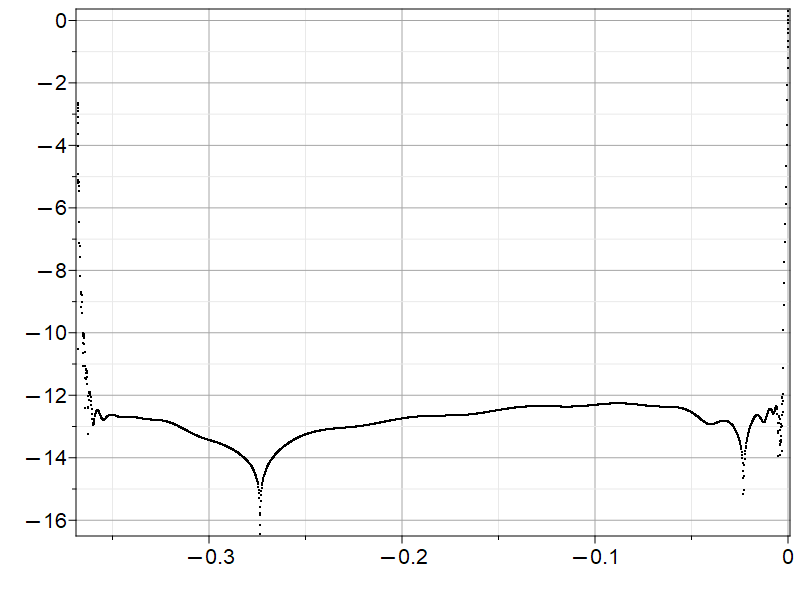

In [75]:
Digits := 30;
plot( x->log10(abs(BaryTCFW0(x)-LambertW(-1,x))), -exp(-1.)..0, 
  style=point, symbol=point, numpoints=2026, gridlines);

In [76]:
Digits := 30:
poleset := convert(finitepoles,set):
resfn := p -> K*mul(p-zz, zz in finitezeros)/mul( p-pp, pp in poleset minus {p}):

In [77]:
latex( evalf[7]([map( p->[p,resfn(p)], finitepoles )]) );

[[[- 0.7949392,  0.2135808], [- 0.5194409,  0.03395705], [- 0.4366312,  0.009392065], [- 0.4013973,  0.003130993], [- 0.3843763,  0.001114384], [- 0.3757436,  0.0003964343], [- 0.3713453,  0.0001328579], [- 0.3691864,  0.00003842298], [- 0.3682318, { 7.898472\times 10^{-6}}], [- 0.3679106, { 5.345774\times 10^{-7}}], [ 0.0001532797,  0.0004366954], [ 0.0008681998,  0.001197881], [ 0.002440324,  0.002447892], [ 0.005477999,  0.004697972], [ 0.01118285,  0.008938977], [ 0.02194710,  0.01730429], [ 0.04285705,  0.03503850], [ 0.08622111,  0.07791069], [ 0.1899974,  0.2128633], [ 0.5519998,  1.029882], [ 48.27600,  3475.998]]]

## Pade approximant ##

In [78]:
Order := numelems(finitezeros)+numelems(finitepoles)+1;

$$43$$

In [79]:
ws := series(LambertW(-1,x),x=-2*exp(-2)) assuming x < 0:

In [80]:
wpade := CodeTools:-Usage( convert(ws,ratpoly) ):

memory used=12.16MiB, alloc change=0 bytes, cpu time=63.00ms, real time=60.00ms, gc time=0ns

In [81]:
top := numer(wpade):
degree(top,x);

$$21$$

In [82]:
bot := denom(wpade):
degree(bot,x);

$$21$$

In [83]:
padezeros := fsolve(top,x,'complex'):
padepoles := fsolve(bot,x,'complex'):

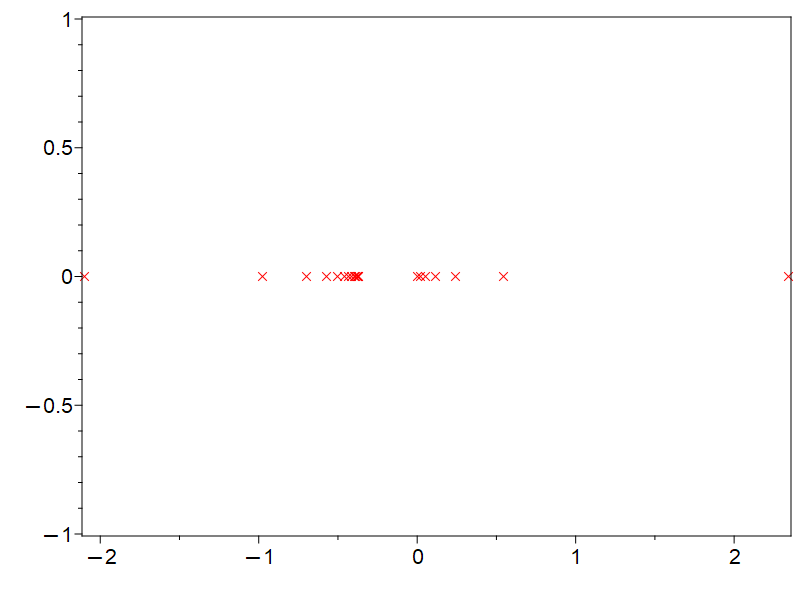

In [84]:
pzplot := plots[complexplot]([padezeros], style=point, 
               colour=red, symbol=diagonalcross);

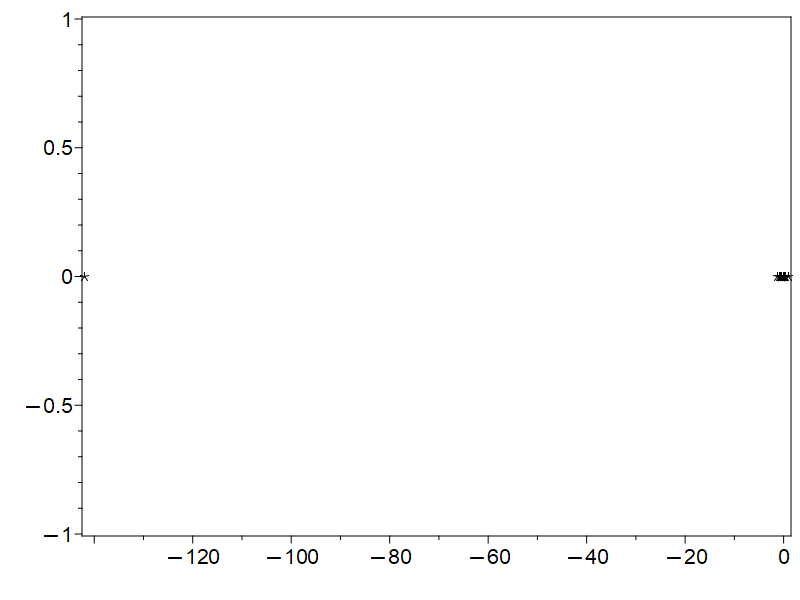

In [85]:
ppplot := plots[complexplot]([padepoles], style=point, 
                  symbol=asterisk, colour=black);

In [86]:
logz := [seq(p+exp(-1.0), p in [padezeros])];

| | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-1.73464292884389066547563808006|-.609429953394884977140721735878|-.328343736217035866722433905413|-.204174737352444758271358151580|-.135610283478984721034435881639|-.92948110710665169912915853789e-1|-.64407496841102089537075559531e-1|-.44416296805813331193966911814e-1|-.30016590123482538589209261268e-1|-.19507918328049181129335463739e-1|-.11857659251221889582362525268e-1|-.6417494397595077680988529087e-2|-.2776800846019293847914020661e-2|-.683325840561274154919712361e-3|.372299085755341516292316380627|.389121114302819117257907346751|.422845743689734897588929371440|.484949045234171221224440679151|.607317046932901617288103871429|.912619455239740317037998528413|2.71410253838567355976069917060|


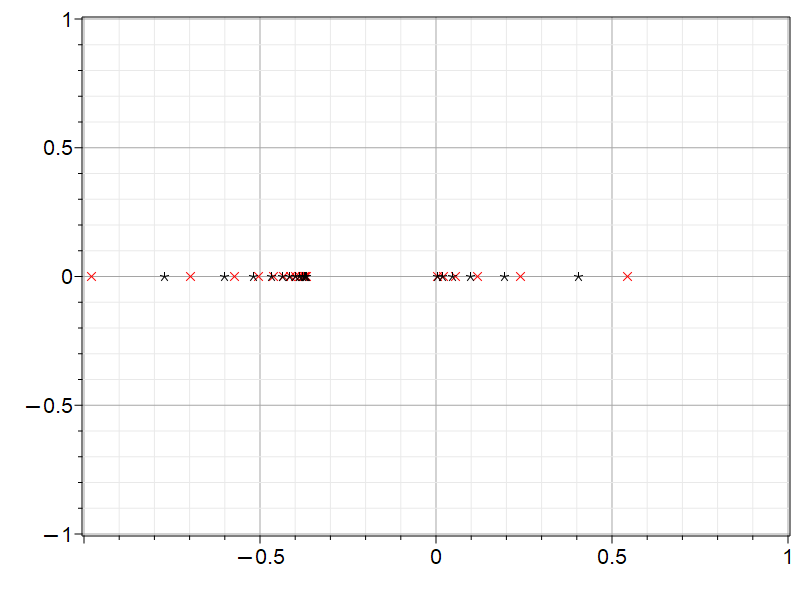

In [87]:
plots[display](pzplot,ppplot, view=[-1..1, default], gridlines)

kilobytes used=502708, alloc=25000, time=33.39

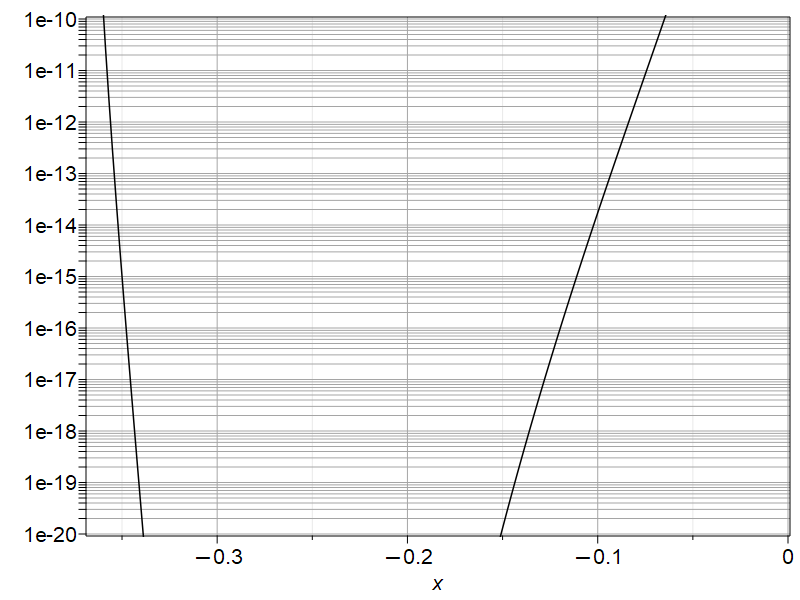

In [88]:
Digits := 30:
plots[logplot](abs( wpade-LambertW(-1,x) ), x=-exp(-1)..0, 
view=[-exp(-1)..0, 1.0e-20..1.0e-10] , gridlines);

In [89]:
evalf[7]( convert(wpade,confrac,x) );

kilobytes used=630547, alloc=27119, time=40.39

$$- 121.3962+\frac{ 17223.84}{x + 142.0509-\frac{ 4.022532}{x - 0.4853428-\frac{ 0.7066132}{x + 0.5171742-\frac{ 0.3824025}{x - 0.0002704185-\frac{ 0.1577321}{x + 0.4200495-\frac{ 0.1289462}{x + 0.04042031-\frac{ 0.07113463}{x + 0.4099429-\frac{ 0.05255854}{x + 0.04493265-\frac{ 0.04819951}{x + 0.3991905-\frac{ 0.01884221}{x + 0.07263003-\frac{ 0.04762191}{x + 0.3554356-\frac{ 0.005484245}{x + 0.1764236-\frac{ 0.05592693}{x + 0.2416021-\frac{ 0.002131796}{x + 0.3586847-\frac{ 0.02446871}{x + 0.06235089-\frac{ 0.003787264}{x + 0.4024513-\frac{ 0.0003425865}{x + 0.3995790-\frac{ 0.0001823357}{x + 0.3907448-\frac{ 0.00008920244}{x + 0.3832850-\frac{ 0.00003601946}{x + 0.3769376-\frac{ 9.253199\times 10^{-6}}{x + 0.3714919}}}}}}}}}}}}}}}}}}}}}$$

In [90]:
leftlogz := [seq(p+exp(-1.0), p in select( t->t<-exp(-1.), [padezeros]) )]:
rightlogz := [seq(p, p in select( t->t>0, [padezeros]))]:

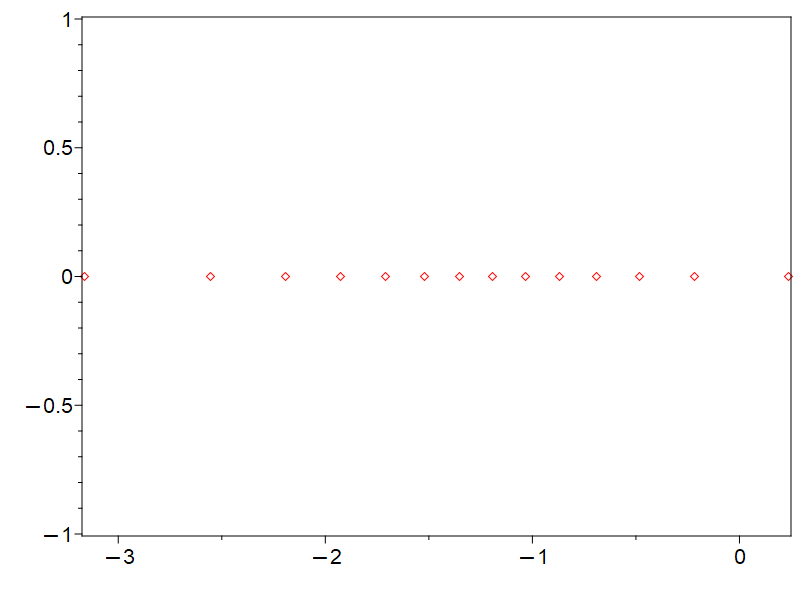

In [91]:
leftzplot := plots[pointplot]( [seq( [log10(-zz),0], zz in leftlogz)], style=point, colour=red );

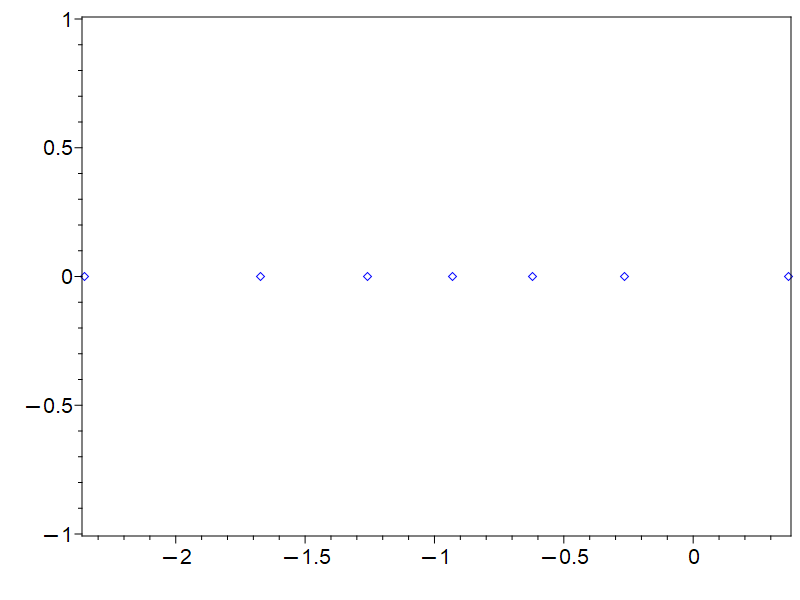

In [92]:
rightzplot := plots[pointplot]( [seq([log10(zz),0], zz in rightlogz)], style=point, colour=blue );

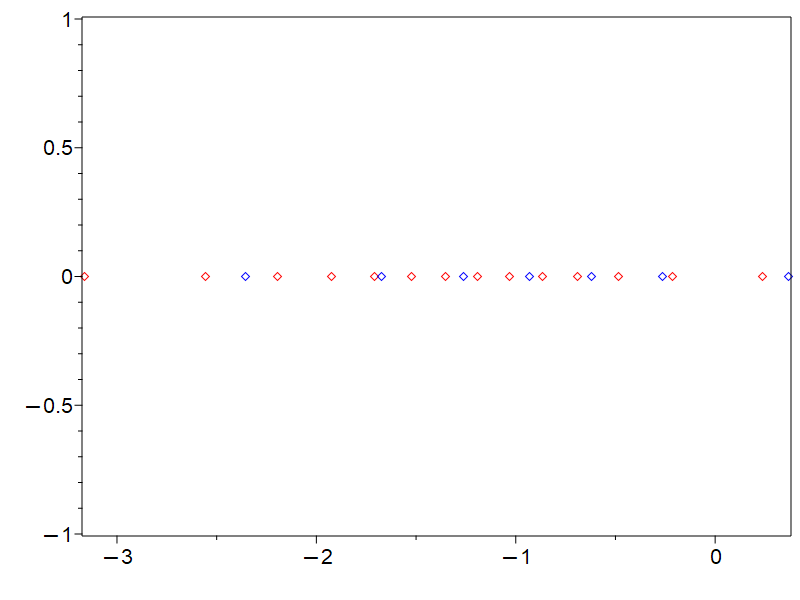

In [93]:
plots[display](leftzplot,rightzplot);